# **Analisis variables - Adultos vs Kids**

Este análisis contiene datos actualizados respecto al análisis presentado en la memoria y la presentación, por lo cuál hay algunas diferencias ligeras en las conclusiones. En algunos casos mencionamos también las conclusiones sacadas en el análisis anterior, ya que proporcionan información adicional relevante.

# Bibliotecas

In [1]:
#Carga de datos
import pandas as pd
import numpy as np
import json
from Server_PD import download_dataframe_minio

from collections import Counter
import re

import seaborn as sns
import matplotlib.pyplot as plt
import isodate

import analisisutils as utils

# Carga de datos

# Transformamos la columna "Duracion"

In [2]:
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]
df = download_dataframe_minio("pd1", "grupo1/clean/union_dfs_20260305",claves=claves,file_format="parquet")
df.tail()

,ID,Titulo,Descripcion,Visualizaciones,Tags,Duracion,Fecha_publicacion,Titulo_canal,Subtitulos,Generos,Subgeneros,Made for kids,Rango_edad
13704,ulzTXwihC_g,The Inmate Teaching Finance Behind Bars,Curtis Carroll is simply known as “Wall Street...,321679,"great big story, gbs, lag, documentary, docs, ...",PT3M55S,2018-07-03 06:00:05+00:00,Great Big Story,Kind: captions Language: en (melodic piano mus...,People & Blogs,Society,False,5-8
13705,W6CBb3yX9Zs,How Is Your Phone Changing You?,Should you be worried about your cellphone?\n6...,5905697,"Science, AsapSCIENCE, Phone, Smartphone, Cellp...",PT3M12S,2016-06-02 16:06:03+00:00,AsapSCIENCE,Kind: captions Language: en of the 7 billion p...,Science & Technology,Technology,False,5-8
13706,VFJMnuEZ4sk,POV me coming back to school after summer brea...,,313163,,PT18S,2025-08-14 21:02:00+00:00,My PB and J,None,People & Blogs,"Entertainment, Humour",False,5-8
13707,7UXd2z0yg1o,Everything I Ate On BULLET TRAINS in JAPAN for...,Experience a Japanese bullet train (or Shinkan...,6846267,"jeanelle eats, janelle eats, food and travel, ...",PT19M46S,2024-03-10 14:00:11+00:00,Jeanelleats,Kind: captions Language: en let's hop on 10 bu...,People & Blogs,"Food, Lifestyle (sociology)",False,5-8
13708,bS1xGetyrh0,How is the NFL Schedule Created? | NFL Explained,Subscribe to NFL Network: http://goo.gl/4GOLwY...,826799,"nfl, nfl network, football, american football",PT21M2S,2021-05-13 00:00:14+00:00,NFL,None,Sports,"American football, Sport",False,5-8


In [3]:

df['Duracion'] = df['Duracion'].apply(utils.iso_a_minutos)

# Dividimos los datos en "Adult" y "Kids"

In [3]:
# Kids
rangos_kids = ['0-4', '5-8', '9-12']
df_Kids = df[df["Rango_edad"].isin(rangos_kids)].copy()

# Adults
df_Adult = df[df["Rango_edad"] == "Adult"].copy()
df_Adult = df_Adult.head(len(df_Kids)).copy()


# Duración

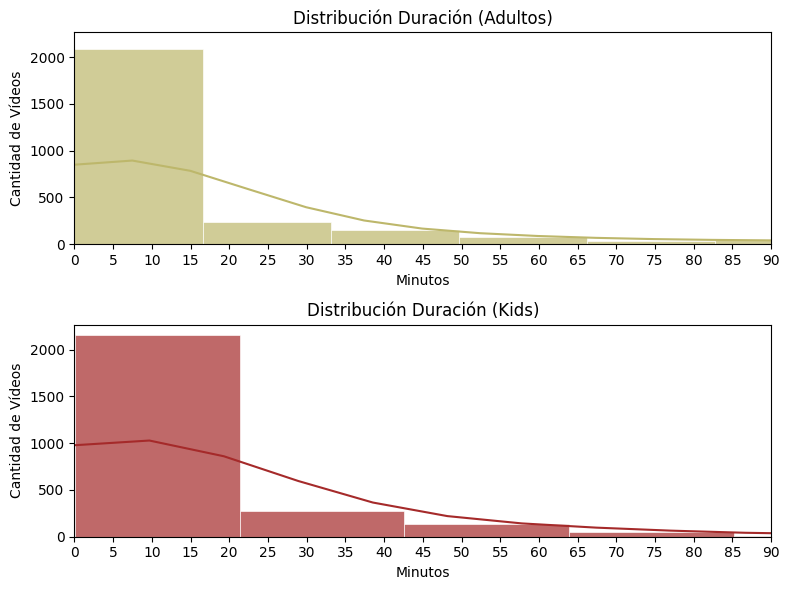

In [5]:

# Configuración
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharey=True)

utils.graficar_histograma_duracion(df_Adult, 'Distribución Duración (Adultos)', ax[0], 'darkkhaki')
utils.graficar_histograma_duracion(df_Kids, 'Distribución Duración (Kids)', ax[1], 'brown')

plt.tight_layout()
plt.show()

Kids: La distribución extremadamente concentrada en duraciones muy cortas (generalmente entre 0 y 10 minutos). Se puede observar que apenas hay videos de más de 15 minutos, lo que indica que el contenido infantil está diseñado para captar la atención de forma rápida y breve.

Adultos: Aunque también tiene un pico en duraciones cortas, hay más variedad. Desde vídeos cortos informativos (de entre 0-15 minutos) hasta contenidos más extensos que el público adulto es capaz de retener.

C:\Users\javil\AppData\Local\Temp\ipykernel_14952\4239985363.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')


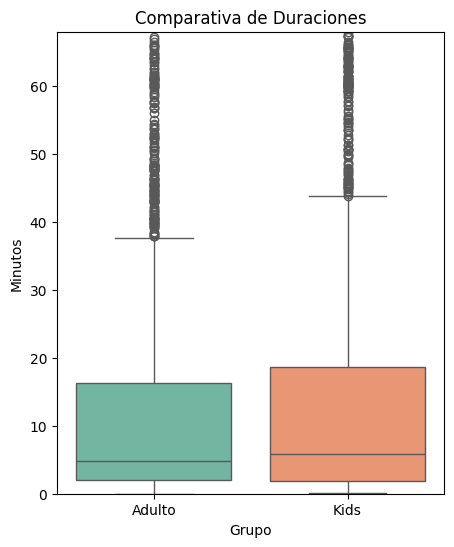

In [6]:
df_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_Kids.assign(Grupo='Kids')
])

plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')     

# zoom para que se vea mejor
limite_superior = df_total['Duracion'].quantile(0.95) * 0.7 
plt.ylim(0, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

Como se puede observar la mediana es prácticamente igual para adultos que para niños. Esto sugiere que hay un tiempo ideal para mantener la atención antes de que el usuario pase al siguiente vídeo, independientemente de su edad. Se puede estimar que este valor está entre 5 y 8 minutos.

En ambos grupos vemos puntos por encima de los bigotes (outliers). En adultos estos valores extremos pueden llegar a duraciones mucho mayores, mientras que en niños, incluso los vídeos que se consideran más largos siguen teniendo una duración razonable.

# Top 10 géneros

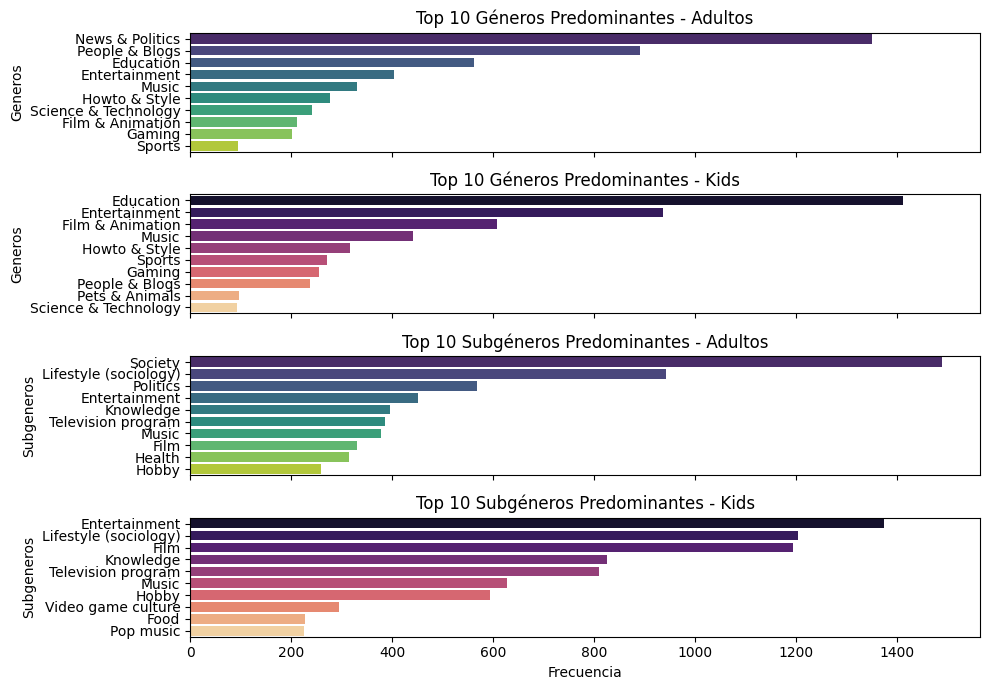

In [5]:
# Configuración
fig, ax = plt.subplots(4, 1, figsize=(10, 7), sharex=True)

# Llamamos a la función para cada grupo
utils.graficar_top_10(df_Adult, 'Top 10 Géneros Predominantes - Adultos', ax[0], 'viridis', "Generos")
utils.graficar_top_10(df_Kids, 'Top 10 Géneros Predominantes - Kids', ax[1], 'magma', "Generos")
utils.graficar_top_10(df_Adult, 'Top 10 Subgéneros Predominantes - Adultos', ax[2], 'viridis', "Subgeneros")
utils.graficar_top_10(df_Kids, 'Top 10 Subgéneros Predominantes - Kids', ax[3], 'magma', "Subgeneros")
plt.tight_layout()
plt.show()

El perfil del público adulto destaca por su fragmentación y heterogeneidad temática. Por un lado, tenemos contenidos informativos y de actualidad ('Blogs', 'Politics', 'Knowledge') y, por otro, un consumo más de ocio ('Music', 'Gaming'). 

En cuanto al público infantil, lso temas mas comunes son; 'Entertainment', 'Music', 'Film'. Se observa que los contenidos se inclinan más hacia temas lúdicos. Aunque tambien observamos cierto caracter educativo con generos como 'Knowledge'.

Observamos que los géneros más voluminosos (Education, Entertainment, Film & Animation) están presentes en ambos grupos. Esto genera una ambigüedad por lo que consideramos que la frecuencia de género no es suficiente para clasificar con seguridad.

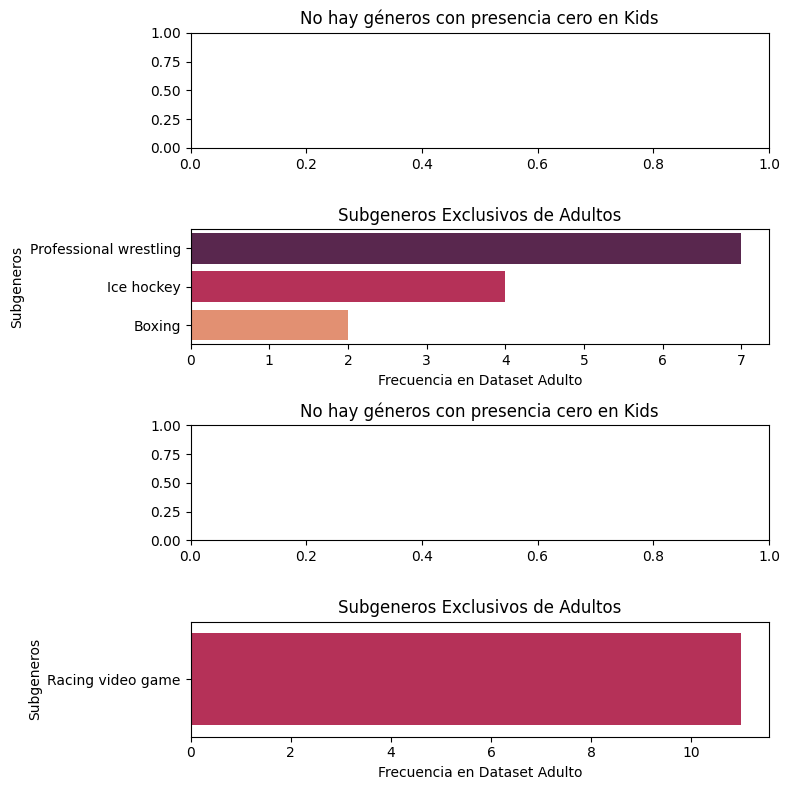

In [7]:
fig, ax = plt.subplots(4, 1, figsize=(8,8))
utils.graficar_generos_ausentes(df_Adult, df_Kids, ax[0], "Generos")
utils.graficar_generos_ausentes(df_Adult, df_Kids, ax[1], "Subgeneros")
utils.graficar_generos_ausentes(df_Kids, df_Adult, ax[2], "Generos")
utils.graficar_generos_ausentes(df_Kids, df_Adult, ax[3], "Subgeneros")
plt.tight_layout()
plt.show()

La utilidad de los géneros en este modelo no reside en la frecuencia de los más usados, sino en la certeza de los ausentes, convirtiendo la escasez de datos en ciertas categorías en una herramienta de filtrado de alta precisión. Al cambiar la muestra de datos, ahora no hay géneros ausentes en Kids, pero antes hemos visto que tales géneros pueden ser, por ejemplo, "Physical Attractiveness", "Professional Wrestling" y "Boxing". 

La ausencia total de estos temas en el grupo Kids nos permite establecer una lista de generos "prohibidos". Si el clasificador detecta una de estas etiquetas en un vídeo, lo mejor es que este sea descartado como apto para niños, independientemente de si su vocabulario o duración sugieren lo contrario.

Por lo que hemos visto, los temas que no son aptos para niños tienen que ver principalente con la violencia.


# Densidad de habla (wpm)

In [10]:
#Agregamos una nueva columna a todos los df
df_Adult['Palabras_Por_Minuto'] = df_Adult.apply(utils.calcular_wpm, axis=1)
df_Adult['Palabras_Por_Minuto'] = round(df_Adult['Palabras_Por_Minuto'], 2)

df_Kids['Palabras_Por_Minuto'] = df_Kids.apply(utils.calcular_wpm, axis=1)
df_Kids['Palabras_Por_Minuto'] = round(df_Kids['Palabras_Por_Minuto'], 2)


C:\Users\Marina\AppData\Local\Temp\ipykernel_35284\3005112938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')


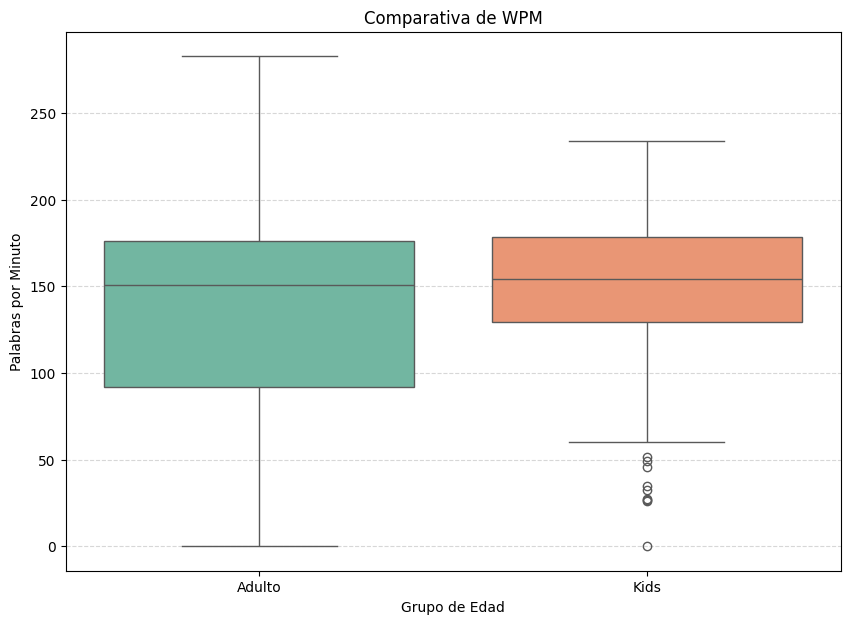

In [16]:
# Filtramos los vídeos sin palabras que no tienen subtitulos
df_wpm_total = pd.concat([
    df_Adult[df_Adult['Palabras_Por_Minuto'] > 0].assign(Grupo='Adulto'),
    df_Kids[df_Kids['Palabras_Por_Minuto'] > 0].assign(Grupo='Kids')
])

#Gráfica
plt.figure(figsize=(10, 7))

sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Comparativa de WPM')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Sorprendentemente, la mediana de palabras por minuto en el grupo Kids es ligeramente superior a la del grupo Adulto. Esto sugiere que, cuando un vídeo infantil es de carácter narrativo o educativo, mantiene un ritmo verbal constante y dinámico para mantener la atención del menor.

La caja del grupo infantil es notablemente más compacta. Esto indica que el contenido para niños sigue un estándar de producción muy rígido, el ritmo de habla es más uniforme.

El grupo Adulto presenta una caja mucho más amplia y bigotes más largos. Esto refleja la enorme heterogeneidad de su contenido; mientras que en Kids el ritmo es predecible, en adultos conviven géneros con una carga de guion mínima junto a otros de altísima densidad verbal.

Para nuestro clasificador, esto significa que el WPM por sí solo no define si un vídeo es para niños o adultos, sino su variabilidad.

Es importante señalar que la muestra de vídeos infantiles con subtítulos disponibles es considerablemente menor que la de adultos. Esto suguiere que los resultados de WPM en el grupo Kids podrían no ser plenamente representativos.

# Keywords 

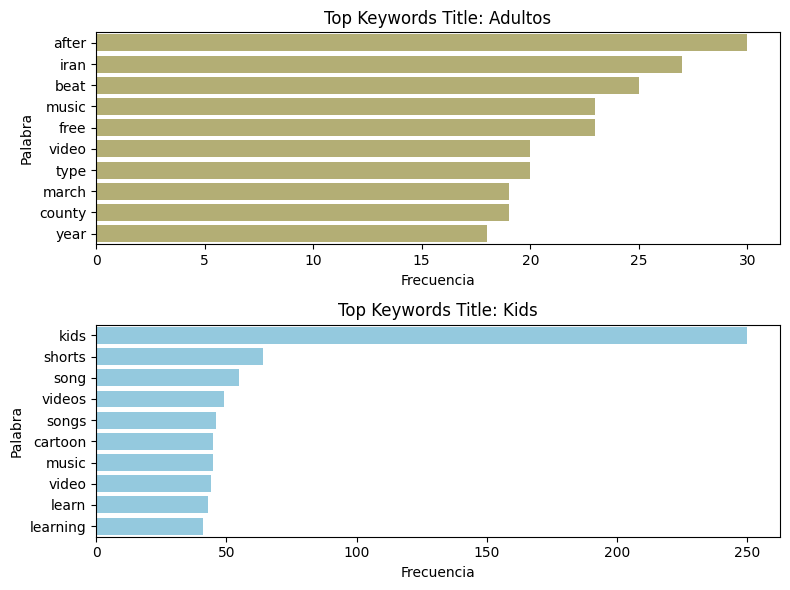

In [11]:
#Palabras más comunes en títulos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

utils.graficar_palabras_comunes(df_Adult, 'Titulo', 'Top Keywords Title: Adultos', ax[0], 'darkkhaki')
utils.graficar_palabras_comunes(df_Kids, 'Titulo', 'Top Keywords Title: Kids', ax[1], 'skyblue')

plt.tight_layout()
plt.show()

Se puede observar que los titulos de los videos adultos tienen un enfoque más informativo. Las palabras clave como 'Trailer', 'News', 'Iran', 'Official' y 'War' (vistos en esta gráfica y en análisis anteriores con otros datos) confirman un consumo basado en la actualidad política y el cine. Los títulos son descriptivos y parece que buscan informar sobre un contenido específico.

Por otro lado los titulos de los videos infantiles aparentan ser mas genéricos. Los términos predominantes son 'kids', 'cartoon', 'song', 'musuc'. Esto refuerza la idea de un consumo lúdico donde se busca el entretenimiento directo.

En el grupo Kids, el uso de la palabra 'kids' es masivo. Esto indica que el modelo de predicción de éxito para niños debería dar mucho peso a esta palabra, ya que define el producto de forma casi inequívoca.

En el grupo Adulto, hemos observado palabras como 'new' y 'day', lo que sugiere que el usuario adulto valora la actualidad del contenido.


**SUBTITULOS**

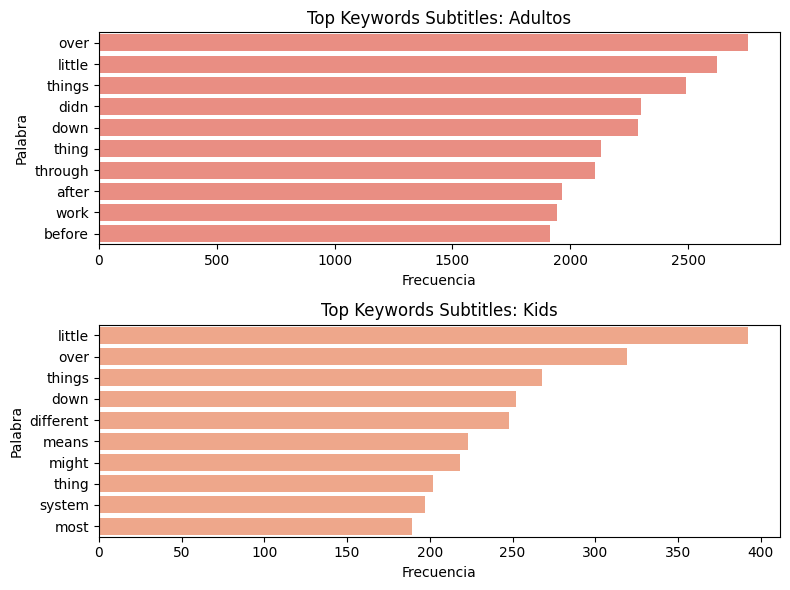

In [18]:
#Palabras mas comunes en subtítulos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

utils.graficar_palabras_comunes(df_Adult, 'Subtitulos', 'Top Keywords Subtitles: Adultos', ax[0], 'salmon')
utils.graficar_palabras_comunes(df_Kids, 'Subtitulos', 'Top Keywords Subtitles: Kids', ax[1], 'lightsalmon')

plt.tight_layout()
plt.show()

In [30]:
topic_model, df_topic_model, temas =  utils.analizar_descripciones_bertopic(df, "Descripcion", "english")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
freq_df = utils.frecuencia_tags(df_Adult, "Tags")
freq_df.head(20)

,Tag,Frecuencia
8,,1198
2,news,263
21,video,135
119,news ],80
4108,News,71
644,[ local,64
3,local news,52
110,politics,48
114,weather,44
772,breaking news,43


In [8]:
freq_df = utils.frecuencia_tags(df_Kids, "Tags")
freq_df.head(20)

,Tag,Frecuencia
211,,585
122,kids,347
38,kids videos,249
157,cartoon,245
938,for kids,221
40,preschool,220
197,cartoons for kids,217
39,nursery rhymes,217
1187,animation,202
121,children,179


In [6]:
tfid_df = utils.tfidf_tags(df_Adult, "Tags")
tfid_df.head(20)

,Tag,Score
12399,news,910.051671
12062,music,537.825906
1891,beat,337.542079
19093,video,314.631354
18611,type,309.924544
5344,drama,257.797290
152,2026,228.842360
5894,english,226.686359
10646,local,224.860580
10477,life,221.814759


In [7]:
tfid_df = utils.tfidf_tags(df_Kids, "Tags")
tfid_df.head(20)

,Tag,Score
9119,kids,3502.672002
17756,videos,1074.459092
15544,songs,1071.616660
2829,cartoon,1022.882688
2836,cartoons,802.101639
3200,children,775.578041
11272,music,729.660902
9561,learning,692.596291
15541,song,691.754056
5666,english,639.381470


In [15]:
ngram_df = utils.ngramas_tags(df_Adult, "Tags", 3)
ngram_df.head(20)

,Ngram,Frecuencia
85433,type beat free,157
38774,how to make,66
85380,type beat 2026,54
92495,yt cc on,46
56610,news local news,33
85541,type beat type,33
8786,beat type beat,31
85379,type beat 2025,31
31768,free type beat,29
56388,news breaking news,25


In [16]:
ngram_df = utils.ngramas_tags(df_Kids, "Tags", 3)
ngram_df.head(20)

,Ngram,Frecuencia
109741,videos for kids,385
39354,for kids kids,349
17311,cartoons for kids,320
94109,songs for kids,203
109161,video for kids,167
16787,cartoon for kids,163
31701,educational videos for,148
48916,how to make,147
78459,pig peppa pig,147
48862,how to draw,144
